In [339]:
!pip install pandas numpy matplotlib statsmodels arch pmdarima tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arch

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [340]:
df = pd.read_excel('/content/Price_dataset.xlsx', index_col='Date', parse_dates=True)

In [341]:
df.index = pd.to_datetime(df.index, format='%b-%y')
df = df.asfreq('MS')

In [342]:
df.head()

,Gram,Moong,Arhar
Date,,,
2014-01-01,103.6,126.5,118.1
2014-02-01,101.7,129.3,118.4
2014-03-01,103.5,132.6,119.0
2014-04-01,102.8,135.5,120.6
2014-05-01,103.1,137.8,121.0


In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


In [344]:
data = df['Gram']

# Descriptive statistics

<Axes: xlabel='Date'>

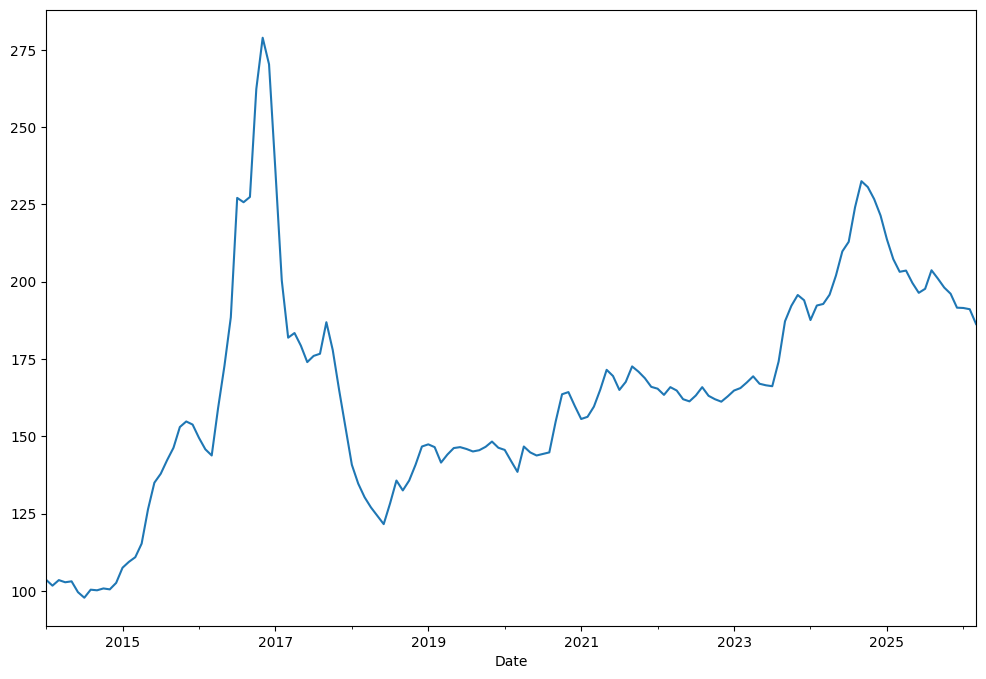

In [345]:
data.plot(figsize=(12,8))

In [346]:
data.describe()

,Gram
count,147.000000
mean,164.361905
std,36.062464
min,97.800000
25%,144.200000
50%,163.400000
75%,188.050000
max,278.900000


In [347]:
data.skew()

np.float64(0.42325089503997976)

In [348]:
data.kurtosis()

np.float64(0.44705601556143515)

## Decompose the series

In [349]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [350]:
decompose = seasonal_decompose(data, model='add')

In [351]:
decompose.seasonal

,seasonal
Date,
2014-01-01,-0.547514
2014-02-01,-5.871757
2014-03-01,-9.181226
2014-04-01,-6.431605
2014-05-01,-5.198651
...,...
2025-11-01,9.220668
2025-12-01,5.915743
2026-01-01,-0.547514


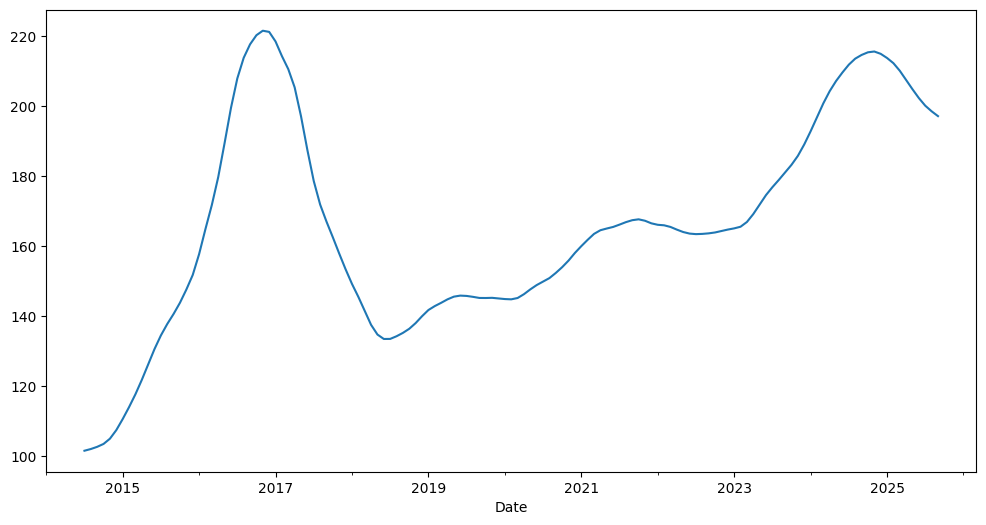

In [352]:
decompose.trend.plot(figsize=(12,6));

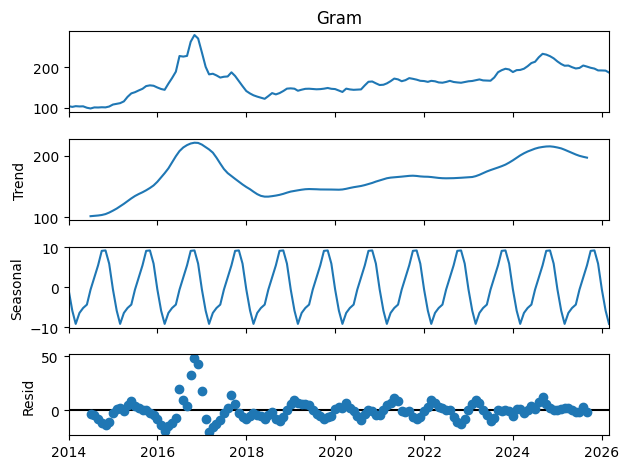

In [353]:
# Plot the decomposition
decompose.plot()
plt.show()

<Axes: >

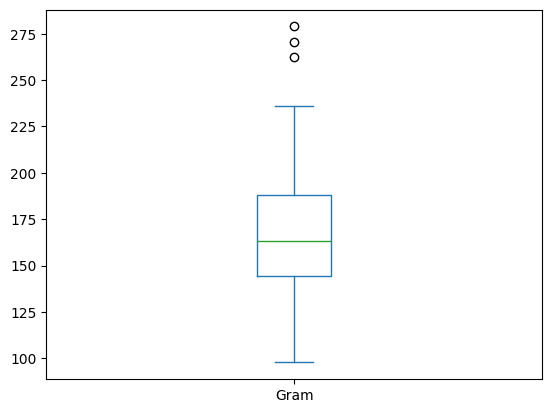

In [354]:
data.plot.box()

# Time series modeling

# Stationarity test

A stationary process has the property that the mean, variance and autocorrelation structure do not change over time.

> $H_0$ : Series is unitroot or non stationary,
>> $H_1$ : Series is stationary

<Axes: xlabel='Date'>

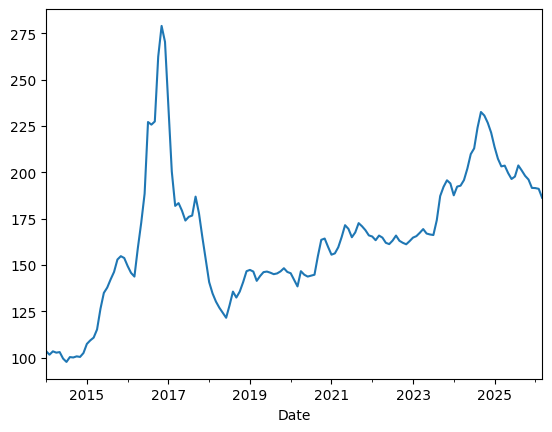

In [355]:
data.plot()

In [356]:
from arch.unitroot import ADF, KPSS, PhillipsPerron

In [357]:
PhillipsPerron(data)

Test Statistic,-2.195
P-value,0.208
Lags,14


In [358]:
ADF(data)

Test Statistic,-3.147
P-value,0.023
Lags,11


#### 1st diff

In [359]:
df_diff = data.diff(periods=1).iloc[1:]

In [360]:
df_diff.head()

,Gram
Date,
2014-02-01,-1.9
2014-03-01,1.8
2014-04-01,-0.7
2014-05-01,0.3
2014-06-01,-3.5


In [361]:
PhillipsPerron(df_diff)

Test Statistic,-5.961
P-value,0.000
Lags,14


In [362]:
df_diff.head()

,Gram
Date,
2014-02-01,-1.9
2014-03-01,1.8
2014-04-01,-0.7
2014-05-01,0.3
2014-06-01,-3.5


In [363]:
ADF(df_diff)

Test Statistic,-5.314
P-value,0.000
Lags,6


##### In diff. 1, the data series are in stationary.

<Axes: xlabel='Date'>

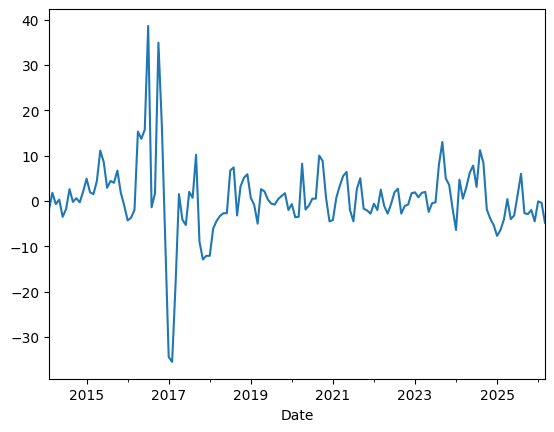

In [364]:
df_diff.plot()

## ACF and PACF plot

>**Autocorrelation** represents the degree of similarity between a given time series and a lagged version of itself over successive time intervals.

> **Partial Autocorrelation** is a conditional correlation.

In [365]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

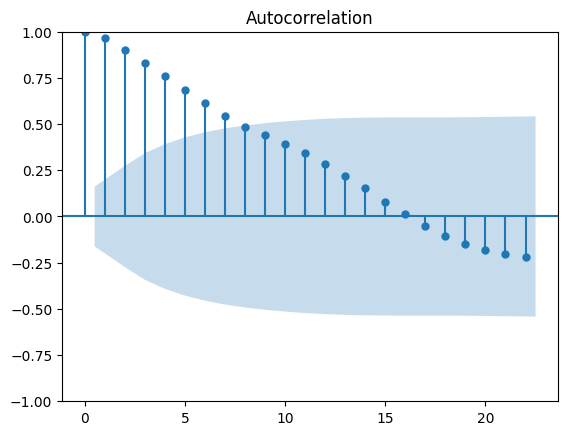

In [366]:
plot_acf(data); # q order

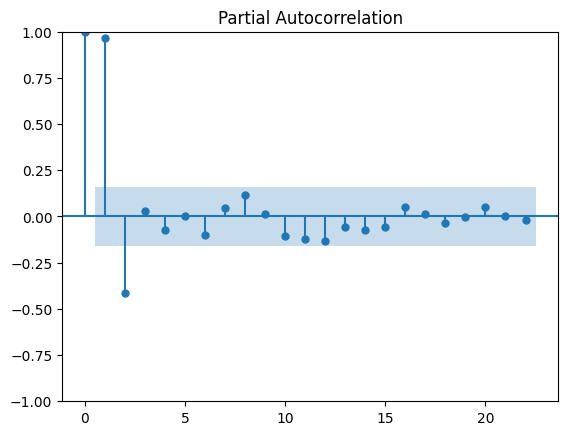

In [367]:
plot_pacf(data); # p order

# AUTO ARIMA

In [368]:
from pmdarima import auto_arima

In [369]:
stepwise_fit = auto_arima(data, start_p=0,start_q=0, max_p=6,max_q=3, m=12, seasonal=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1026.428, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1025.711, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=979.682, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=965.924, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1024.440, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=965.491, Time=0.09 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=965.993, Time=0.12 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=967.843, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=967.404, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=967.437, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=978.338, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=968.782, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[12]             : AIC=963.821, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12]             : AIC=964.245, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12]      

In [370]:
stepwise_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  147
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -479.911
Date:                Mon, 20 Apr 2026   AIC                            963.821
Time:                        20:02:38   BIC                            969.788
Sample:                    01-01-2014   HQIC                           966.246
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.7177      0.034     21.196      0.000       0.651       0.784
sigma2        41.7325      2.817     14.814      0.000      36.211      47.254
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               193.33
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               0.17   Skew:                             0.10
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [371]:
from statsmodels.tsa.arima_model import ARIMA, ARIMAResults

In [372]:
from statsmodels.tsa.arima.model import ARIMA

In [373]:
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


In [375]:
train = df.iloc[:132]
test = df.iloc[132:]

In [376]:
len(test)

15

In [377]:
train.tail()

,Gram,Moong,Arhar
Date,,,
2024-08-01,224.1,190.2,303.8
2024-09-01,232.5,192.5,300.1
2024-10-01,230.6,190.9,290.2
2024-11-01,226.7,187.1,286.9
2024-12-01,221.4,186.0,273.8


In [378]:
test.head()

,Gram,Moong,Arhar
Date,,,
2025-01-01,213.7,189.3,259.1
2025-02-01,207.3,188.8,238.8
2025-03-01,203.2,187.2,229.8
2025-04-01,203.6,187.8,221.8
2025-05-01,199.6,187.9,214.8


## ARIMA Model for Gram


ARIMA(p,d,q)

In [379]:
model_gram = ARIMA(train['Gram'], order=(1,1,0))

result_gram = model_gram.fit()
result_gram.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   Gram   No. Observations:                  132
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -441.750
Date:                Mon, 20 Apr 2026   AIC                            887.500
Time:                        20:02:38   BIC                            893.251
Sample:                    01-01-2014   HQIC                           889.837
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5360      0.040     13.489      0.000       0.458       0.614
sigma2        49.5906      2.750     18.033      0.000      44.201      54.981
===================================================================================
Ljung-Box (L1) (Q):                   1.79   Jarque-Bera (JB):               362.77
Prob(Q):                              0.18   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                             0.44
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [380]:
prediction_gram = result_gram.predict(start=len(train),end=len(train)+len(test)-1, typ='levels').rename('ARIMA(1,1,0)-predictions')

In [381]:
prediction_gram

,"ARIMA(1,1,0)-predictions"
2025-01-01,218.559237
2025-02-01,217.036607
2025-03-01,216.220488
2025-04-01,215.783054
2025-05-01,215.548592
2025-06-01,215.422922
2025-07-01,215.355564
2025-08-01,215.319460
2025-09-01,215.300109
2025-10-01,215.289737


In [382]:
test['ARIMA_prediction']= prediction_gram

<Axes: title={'center': 'True prediction_ARIMA'}, xlabel='Date'>

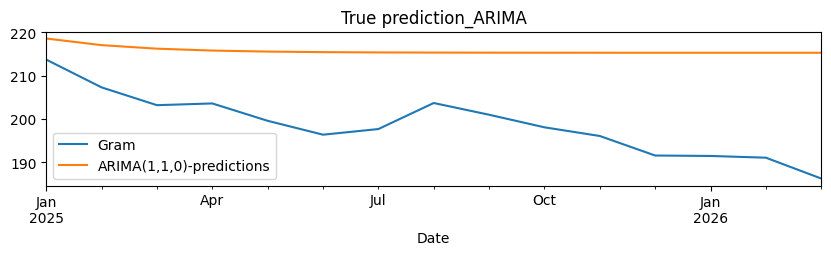

In [383]:
test['Gram'].plot(figsize=(10,2), legend=True, title='True prediction_ARIMA')
prediction_gram.plot(legend=True)

## Error estimation

In [384]:
from statsmodels.tools.eval_measures import rmse, mse

In [385]:
rmse(test['Gram'],prediction_gram)

np.float64(18.107029339271612)

In [386]:
mse(test['Gram'],prediction_gram)

np.float64(327.8645114932429)

In [387]:
test['Gram'].mean()

np.float64(198.72666666666663)

In [388]:
prediction_gram.mean()

np.float64(215.7491850659902)

# Final Model Forecasting

In [389]:
FinalModel_gram = ARIMA(data, order=(1,1,0))

FinalResult_gram = FinalModel_gram.fit()

In [390]:
FinalResult_gram.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   Gram   No. Observations:                  147
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -486.258
Date:                Mon, 20 Apr 2026   AIC                            976.517
Time:                        20:02:38   BIC                            982.484
Sample:                    01-01-2014   HQIC                           978.942
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5368      0.037     14.699      0.000       0.465       0.608
sigma2        45.6438      2.322     19.661      0.000      41.094      50.194
===================================================================================
Ljung-Box (L1) (Q):                   1.95   Jarque-Bera (JB):               474.09
Prob(Q):                              0.16   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                             0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [391]:
forecast_gram = FinalResult_gram.predict(start=len(df),end=len(df)+12, typ='levels').rename('ARIMA(1,1,0)-forecast')

<Axes: xlabel='Date'>

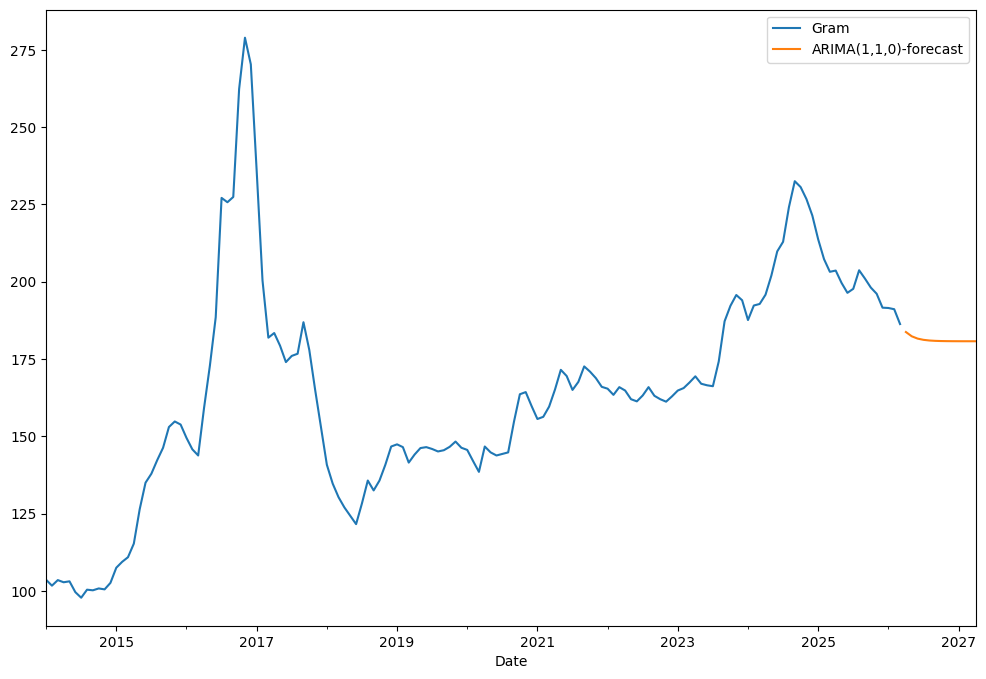

In [392]:
data.plot(figsize=(12,8),legend=True)
forecast_gram.plot(legend=True)

In [393]:
print(forecast_gram)

2026-04-01    183.723369
2026-05-01    182.340238
2026-06-01    181.597777
2026-07-01    181.199224
2026-08-01    180.985282
2026-09-01    180.870439
2026-10-01    180.808791
2026-11-01    180.775698
2026-12-01    180.757934
2027-01-01    180.748399
2027-02-01    180.743280
2027-03-01    180.740532
2027-04-01    180.739057
Freq: MS, Name: ARIMA(1,1,0)-forecast, dtype: float64


# Kolmogorov-Smirnov test for goodness of fit. Normality of residuals

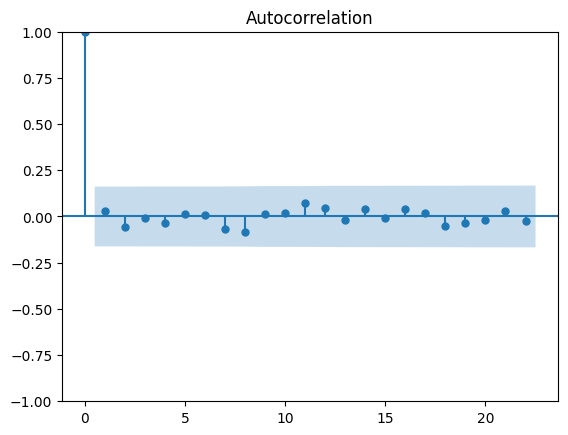

In [394]:
plot_acf(FinalResult_gram.resid);

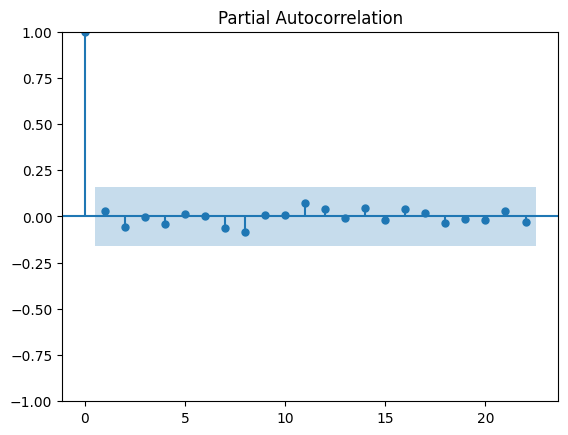

In [395]:
plot_pacf(FinalResult_gram.resid);

<Axes: xlabel='Date'>

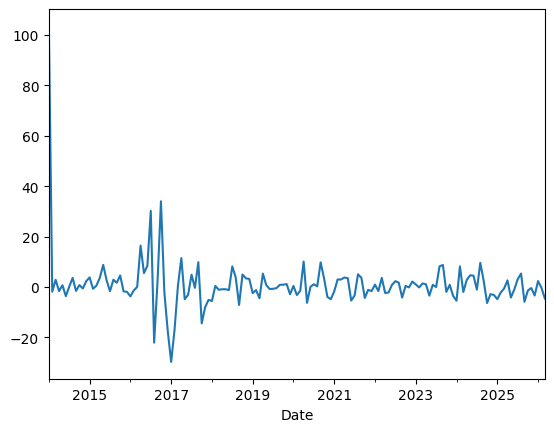

In [396]:
FinalResult_gram.resid.plot()

<Axes: ylabel='Frequency'>

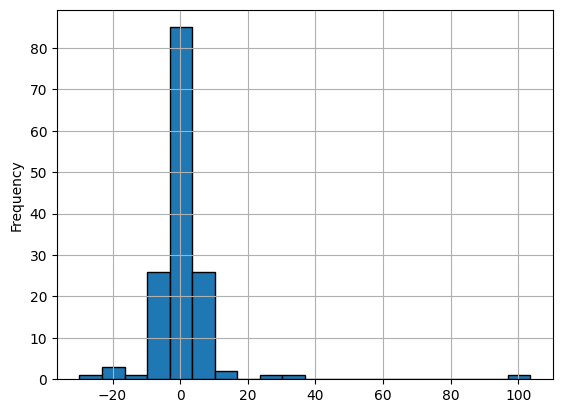

In [397]:
FinalResult_gram.resid.plot.hist(bins=20,grid=True,edgecolor='k')

##### Normality test

In [398]:
stats.kstest(FinalResult_gram.resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.3167243338880531), pvalue=np.float64(1.308241213877235e-13), statistic_location=np.float64(2.1294384893446647), statistic_sign=np.int8(-1))

In [399]:
stats.shapiro(FinalResult_gram.resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.5295993506620893), pvalue=np.float64(8.980031995047558e-20))

In [400]:
from statsmodels.graphics.tsaplots import quarter_plot, month_plot

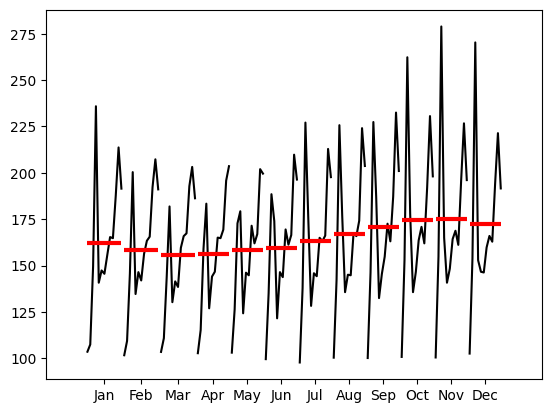

In [401]:
month_plot(data);

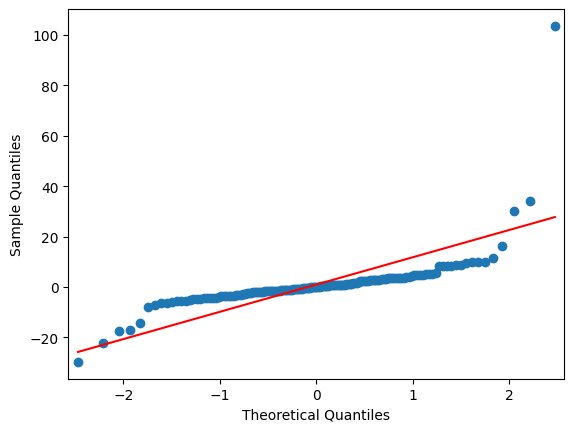

In [402]:
import numpy as np
import statsmodels.api as sm
import pylab


sm.qqplot(FinalResult_gram.resid, line='s');

In [403]:
sm.stats.diagnostic.acorr_ljungbox(FinalResult_gram.resid, lags=[30],return_df=True)

,lb_stat,lb_pvalue
30,14.117013,0.993855


# ARIMA-GARCH

In [404]:
sm.stats.diagnostic.het_arch(FinalResult_gram.resid, nlags=10)

(np.float64(67.00038309978785),
 np.float64(1.676475098423371e-10),
 12.060134961321033,
 1.987708306069769e-14)

In [405]:
resid= FinalResult_gram.resid

In [406]:
resid

,0
Date,
2014-01-01,103.600000
2014-02-01,-1.903566
2014-03-01,2.819916
2014-04-01,-1.666237
2014-05-01,0.675759
...,...
2025-11-01,-0.443285
2025-12-01,-3.426404
2026-01-01,2.315592


In [407]:
resid_train = resid.iloc[:132]
resid_test = resid.iloc[132:]

In [408]:
from arch import arch_model

In [409]:
model_garch = arch_model(resid_train , mean='constant', vol='GARCH', p=1, q=1)
results_garch = model_garch.fit(update_freq = 5)
results_garch.summary()

Iteration:      5,   Func. Count:     30,   Neg. LLF: 424.2473286613433
Iteration:     10,   Func. Count:     55,   Neg. LLF: 423.87316773323647
Optimization terminated successfully    (Exit mode 0)
            Current function value: 423.87149984270854
            Iterations: 14
            Function evaluations: 74
            Gradient evaluations: 14


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -423.871
Distribution:                  Normal   AIC:                           855.743
Method:            Maximum Likelihood   BIC:                           867.274
                                        No. Observations:                  132
Date:                Mon, Apr 20 2026   Df Residuals:                      131
Time:                        20:02:40   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.8794      0.411      2.141  3.228e-02 [7.433e-02,  1.684]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          8.2251      3.141      2.619  8.824e-03   [  2.069, 14.381]
alpha[1]       0.7032      0.415      1.695  9.008e-02   [ -0.110,  1.516]
beta[1]        0.2821      0.140      2.017  4.369e-02 [7.982e-03,  0.556]
==========================================================================

Covariance estimator: robust
"""

In [410]:
resid_test

,0
Date,
2025-01-01,-4.854970
2025-02-01,-2.266655
2025-03-01,-0.664492
2025-04-01,2.600872
2025-05-01,-4.214719
2025-06-01,-1.052808
2025-07-01,3.017754
2025-08-01,5.302162
2025-09-01,-5.920789


In [411]:
rolling_predictions = []
test_size = 15

for i in range(test_size):
    train = resid[:-(test_size-i)]
    model = arch_model(train, mean='constant', vol='GARCH', p=1, q=1)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [412]:
rolling_predictions = pd.Series(rolling_predictions, index=resid.index[-15:])

In [413]:
rolling_predictions

,0
Date,
2025-01-01,5.417876
2025-02-01,6.275735
2025-03-01,5.083371
2025-04-01,4.123398
2025-05-01,3.889997
2025-06-01,5.411450
2025-07-01,4.322083
2025-08-01,4.113360
2025-09-01,5.136268


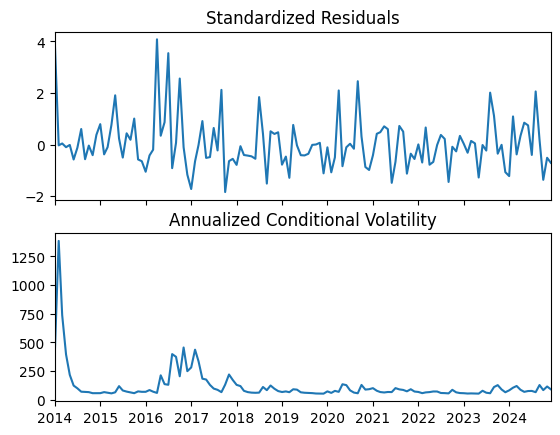

In [414]:
results_garch.plot(annualize='D');

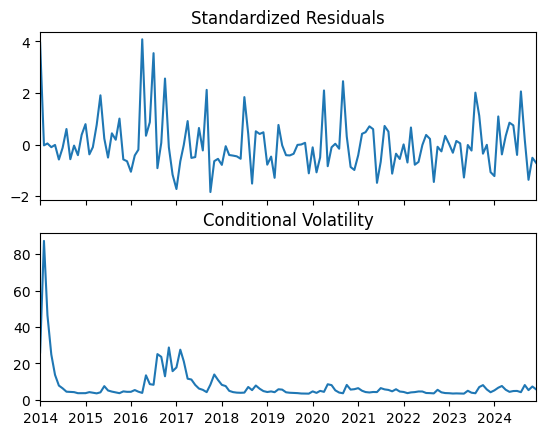

In [415]:
results_garch.plot();

## Normality Check

<Axes: ylabel='Frequency'>

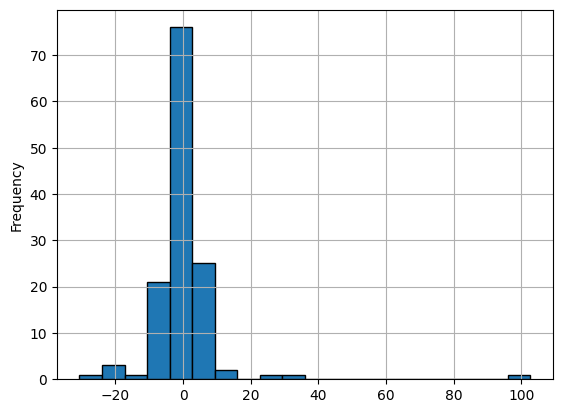

In [416]:
results_garch.resid.plot.hist(bins=20,grid=True,edgecolor='k')

In [417]:
stats.kstest(results_garch.std_resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.12461181836778856), pvalue=np.float64(0.03028853606634757), statistic_location=np.float64(0.0674878507078456), statistic_sign=np.int8(1))

In [418]:
stats.shapiro(results_garch.std_resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.8888510206197807), pvalue=np.float64(1.710322568047844e-08))

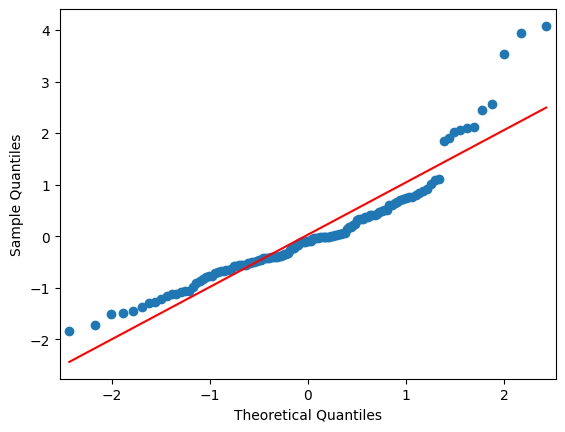

In [419]:
import numpy as np
import statsmodels.api as sm


sm.qqplot(results_garch.std_resid, line='s');

In [420]:
sm.stats.diagnostic.acorr_ljungbox(results_garch.resid, lags=[15], return_df=True)

,lb_stat,lb_pvalue
15,3.907147,0.998026


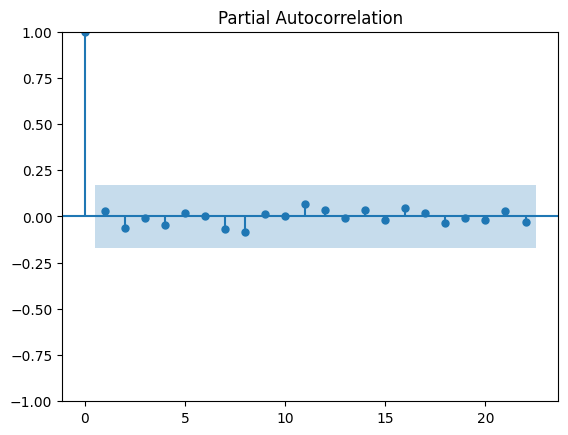

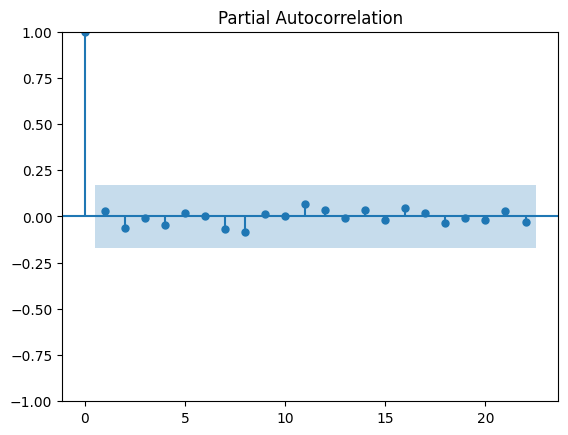

In [421]:
plot_pacf(results_garch.resid)

<Axes: xlabel='Date'>

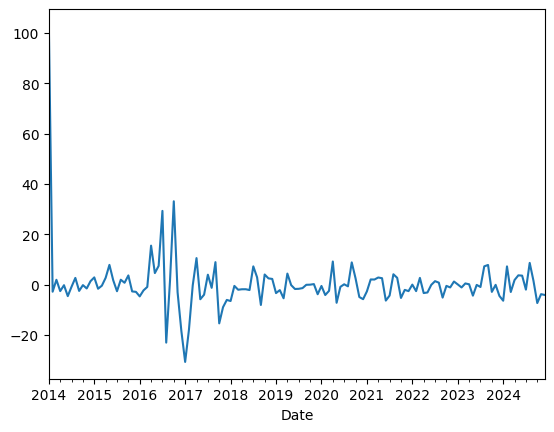

In [422]:
results_garch.resid.plot()

In [423]:
test

,Gram,Moong,Arhar,ARIMA_prediction
Date,,,,
2025-01-01,213.7,189.3,259.1,218.559237
2025-02-01,207.3,188.8,238.8,217.036607
2025-03-01,203.2,187.2,229.8,216.220488
2025-04-01,203.6,187.8,221.8,215.783054
2025-05-01,199.6,187.9,214.8,215.548592
2025-06-01,196.4,184.9,205.6,215.422922
2025-07-01,197.7,183.5,197.6,215.355564
2025-08-01,203.7,186.7,196.2,215.319460
2025-09-01,201.0,187.4,193.4,215.300109


In [424]:
prediction_gram

,"ARIMA(1,1,0)-predictions"
2025-01-01,218.559237
2025-02-01,217.036607
2025-03-01,216.220488
2025-04-01,215.783054
2025-05-01,215.548592
2025-06-01,215.422922
2025-07-01,215.355564
2025-08-01,215.319460
2025-09-01,215.300109
2025-10-01,215.289737


In [425]:
predicted_mu = result_gram.forecast()[0]

In [426]:
predicted_mu

np.float64(218.55923650545563)

In [427]:
garch_forecast = results_garch.forecast(horizon=1)

In [428]:
predicted_et = garch_forecast.mean['h.1'].iloc[-1]

In [429]:
predicted_et

np.float64(0.8794098261688489)

In [430]:
prediction = predicted_mu+predicted_et

In [431]:
prediction_GARCH = prediction_gram+rolling_predictions

In [432]:
prediction_GARCH

,0
2025-01-01,223.977113
2025-02-01,223.312342
2025-03-01,221.303858
2025-04-01,219.906452
2025-05-01,219.438589
2025-06-01,220.834372
2025-07-01,219.677646
2025-08-01,219.432821
2025-09-01,220.436378
2025-10-01,222.017990


In [433]:
rmse(test['Gram'],prediction_GARCH)

np.float64(22.598646684859805)

In [434]:
prediction_GARCH.shape

(15,)

In [435]:
test['Gram'].shape

(15,)

In [436]:
prediction_gram.shape

(15,)

In [437]:
mse(test['Gram'],prediction_GARCH)

np.float64(510.698831987125)

In [438]:
!pip install diebold_mariano_test

In [439]:
from diebold_mariano_test import cul_d_t,MAE,MSE,cul_DM,cul_P

In [440]:
dm = cul_d_t(MAE,test['Gram'],prediction_gram,prediction_GARCH)

In [441]:
cul_DM(dm)

np.float64(-21.52721014133658)

In [442]:
cul_P(dm)

np.float64(8.659187716212946e-103)

In [443]:
MAE(3,test['Gram'],prediction_gram)

np.float64(13.020487825462425)

In [444]:
dm1=cul_d_t(MAE,test['Gram'],prediction_GARCH,prediction_gram)

In [445]:
cul_DM(dm1)

np.float64(21.52721014133658)

In [446]:
test['GARCH_prediction']= prediction_GARCH

# ARIMA-LSTM

### Lag estimation

In [447]:
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot
from pandas import DataFrame

In [448]:
acf(FinalResult_gram.resid**2,nlags=12,qstat=True)

(array([ 1.00000000e+00,  3.16944695e-03,  3.83308743e-03,  1.46323683e-02,
        -2.55491513e-04,  1.03060868e-03,  5.70404945e-03, -2.53378228e-03,
        -3.97090582e-03, -1.48574225e-03, -5.28056520e-03, -5.14532899e-03,
        -3.07760285e-03]),
 array([0.00150702, 0.0037264 , 0.03629285, 0.03630285, 0.03646668,
        0.04152086, 0.04252528, 0.04500995, 0.0453603 , 0.04981834,
        0.05408209, 0.05561881]),
 array([0.96903366, 0.99813853, 0.99818102, 0.99983724, 0.99998667,
        0.99999853, 0.99999988, 0.99999999, 1.        , 1.        ,
        1.        , 1.        ]))

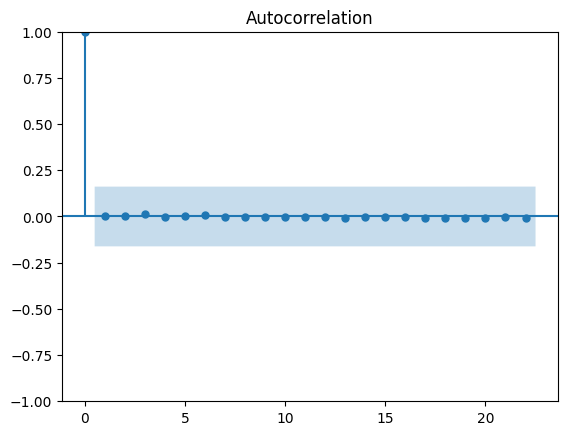

In [449]:
plot_acf(FinalResult_gram.resid**2);

In [450]:
df['resid'] = FinalResult_gram.resid**2

In [451]:
df

,Gram,Moong,Arhar,resid
Date,,,,
2014-01-01,103.6,126.5,118.1,10732.960000
2014-02-01,101.7,129.3,118.4,3.623562
2014-03-01,103.5,132.6,119.0,7.951929
2014-04-01,102.8,135.5,120.6,2.776344
2014-05-01,103.1,137.8,121.0,0.456650
...,...,...,...,...
2025-11-01,196.1,188.1,197.8,0.196502
2025-12-01,191.6,188.5,196.6,11.740243
2026-01-01,191.5,189.8,202.2,5.361964


In [452]:
mylist= ['resid']

df1 = df[mylist][1:]
df1.head()

,resid
Date,
2014-02-01,3.623562
2014-03-01,7.951929
2014-04-01,2.776344
2014-05-01,0.456650
2014-06-01,13.403210


In [453]:
dataframe = DataFrame()
for i in range(9,0,-1):
    dataframe['t-'+str(i)] = df1.shift(i).values[:,0]
dataframe['t'] = df1.values[:,0]
print(dataframe.head(10))
dataframe = dataframe[10:]

        t-9       t-8       t-7       t-6        t-5        t-4        t-3  \
0       NaN       NaN       NaN       NaN        NaN        NaN        NaN   
1       NaN       NaN       NaN       NaN        NaN        NaN        NaN   
2       NaN       NaN       NaN       NaN        NaN        NaN        NaN   
3       NaN       NaN       NaN       NaN        NaN        NaN   3.623562   
4       NaN       NaN       NaN       NaN        NaN   3.623562   7.951929   
5       NaN       NaN       NaN       NaN   3.623562   7.951929   2.776344   
6       NaN       NaN       NaN  3.623562   7.951929   2.776344   0.456650   
7       NaN       NaN  3.623562  7.951929   2.776344   0.456650  13.403210   
8       NaN  3.623562  7.951929  2.776344   0.456650  13.403210   0.006208   
9  3.623562  7.951929  2.776344  0.456650  13.403210   0.006208  12.718043   

         t-2        t-1          t  
0        NaN        NaN   3.623562  
1        NaN   3.623562   7.951929  
2   3.623562   7.951929   2.77

In [454]:
dataframe.to_csv('lags_12months_features.csv', index=False)

In [455]:
dataframe = pd.read_csv('lags_12months_features.csv', header=0)
array = dataframe.values

In [456]:
X = array[:,0:-1]
y = array[:,-1]

In [457]:
model = RandomForestRegressor(n_estimators=100, random_state=1)
model.fit(X, y)

RandomForestRegressor(random_state=1)

In [458]:
print(model.feature_importances_)

[0.0319232  0.01931194 0.03425445 0.02390816 0.05102576 0.19859227
 0.53714882 0.01901268 0.08482272]


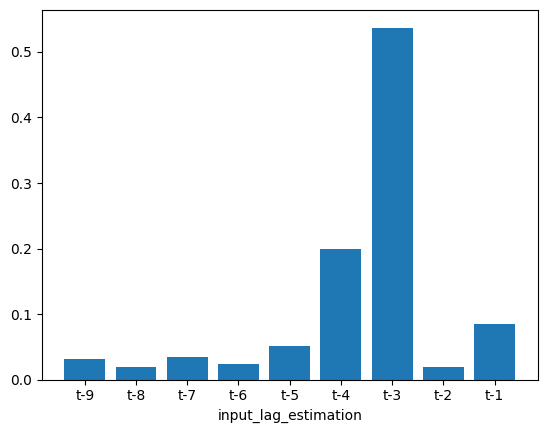

In [459]:
names = dataframe.columns.values[0:-1]
ticks = [i for i in range(len(names))]
pyplot.bar(ticks, model.feature_importances_)
pyplot.xticks(ticks, names)
pyplot.xlabel('input_lag_estimation')
pyplot.show()

In [460]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 146 entries, 2014-02-01 to 2026-03-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   resid   146 non-null    float64
dtypes: float64(1)
memory usage: 2.3 KB


In [461]:
train_resid = df1.iloc[:131]
test_resid = df1.iloc[131:]

In [462]:
train_resid

,resid
Date,
2014-02-01,3.623562
2014-03-01,7.951929
2014-04-01,2.776344
2014-05-01,0.456650
2014-06-01,13.403210
...,...
2024-08-01,90.933882
2024-09-01,5.701881
2024-10-01,41.076616


In [463]:
test_resid

,resid
Date,
2025-01-01,23.570734
2025-02-01,5.137723
2025-03-01,0.441550
2025-04-01,6.764537
2025-05-01,17.763858
2025-06-01,1.108404
2025-07-01,9.106839
2025-08-01,28.112927
2025-09-01,35.055738


In [464]:
from sklearn.preprocessing import MinMaxScaler

In [465]:
scaler = MinMaxScaler()
scaler.fit(train_resid)

MinMaxScaler()

In [466]:
scaled_train = scaler.transform(train_resid)
scaled_test = scaler.transform(test_resid)

In [467]:
scaled_test

array([[0.02040481],
       [0.00444752],
       [0.00038208],
       [0.00585583],
       [0.01537785],
       [0.00095937],
       [0.00788355],
       [0.02433695],
       [0.03034728],
       [0.00182157],
       [0.00016994],
       [0.01016326],
       [0.00464164],
       [0.00010366],
       [0.01820082]])

In [468]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [469]:
# Define the generator
n_input = 1 # how many data will estimate the next time stand value.
n_features = 1

train_generator = TimeseriesGenerator(scaled_train,scaled_train,length=n_input,batch_size=1)

In [470]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.utils import plot_model

In [471]:
model = Sequential()

model.add(LSTM(66, activation='relu', input_shape =(n_input,n_features)))    #relu = rectified linear unit
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

In [472]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 66)             │        17,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            67 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,019 (70.39 KB)

 Trainable params: 18,019 (70.39 KB)

 Non-trainable params: 0 (0.00 B)

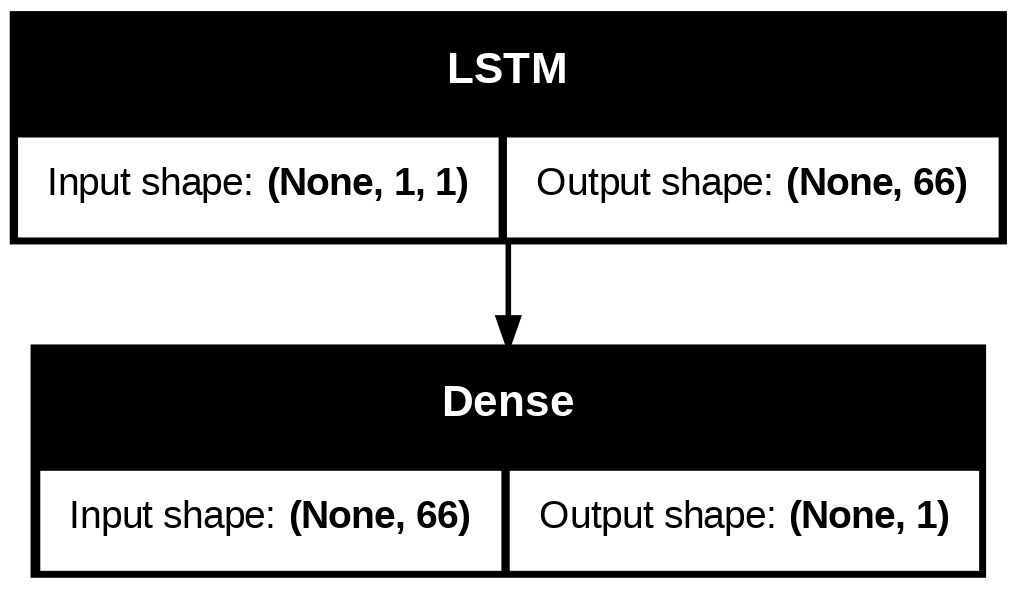

In [473]:
plot_model(model,show_shapes=True)

In [474]:
model.fit(train_generator, epochs=25)

Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0194
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0186
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0185
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183
Epoch 6/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183
Epoch 7/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181
Epoch 8/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181
Epoch 9/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183
Epoch 10/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0182
Epoch 11/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181
Epoch 12/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0180
Epoch 13/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180
Epoch 14/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181
Epoch 15/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

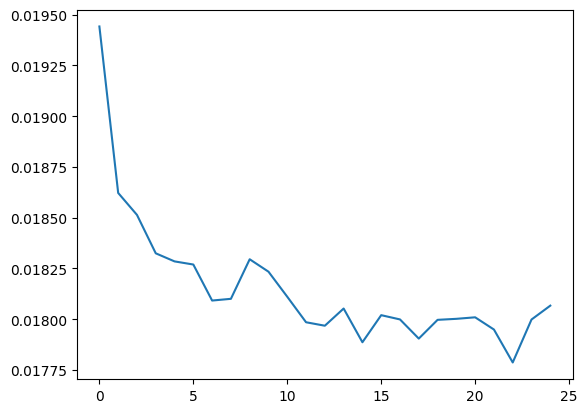

In [475]:
myloss = model.history.history['loss']

plt.plot(range(len(myloss)),myloss)

In [476]:
# Holding my prediction
test_prediction = []

# Last n_input point from the train set
first_eval_batch= scaled_train[-n_input:]

# Reshape this to the RNN format. same as TimeSeriesGenarator
current_batch = first_eval_batch.reshape((1,n_input,n_features))

# How far will we forecast?

for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]

    test_prediction.append(current_pred)

    current_batch= np.append(current_batch[:,1:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [477]:
test_prediction

[array([0.02809628], dtype=float32),
 array([0.03206153], dtype=float32),
 array([0.03288136], dtype=float32),
 array([0.03305089], dtype=float32),
 array([0.03308596], dtype=float32),
 array([0.03309329], dtype=float32),
 array([0.03309482], dtype=float32),
 array([0.03309514], dtype=float32),
 array([0.03309521], dtype=float32),
 array([0.03309522], dtype=float32),
 array([0.03309523], dtype=float32),
 array([0.03309523], dtype=float32),
 array([0.03309523], dtype=float32),
 array([0.03309523], dtype=float32),
 array([0.03309523], dtype=float32)]

In [478]:
true_prediction = scaler.inverse_transform(test_prediction)

In [479]:
true_prediction = true_prediction[:15]


In [480]:
test_resid['resid']

,resid
Date,
2025-01-01,23.570734
2025-02-01,5.137723
2025-03-01,0.441550
2025-04-01,6.764537
2025-05-01,17.763858
2025-06-01,1.108404
2025-07-01,9.106839
2025-08-01,28.112927
2025-09-01,35.055738


In [481]:
test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'] = true_prediction

In [482]:
test_resid['Prediction Volatility ARIMA-GARCH']= rolling_predictions
test_resid['true Volatility']= resid_test
test_resid.to_csv('Gram volatility.csv')

In [483]:
test['ARIMA-LSTM_Pred']= test['ARIMA_prediction']+test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)']

In [484]:
test

,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,218.559237,223.977113,251.014738
2025-02-01,207.3,188.8,238.8,217.036607,223.312342,254.072553
2025-03-01,203.2,187.2,229.8,216.220488,221.303858,254.203451
2025-04-01,203.6,187.8,221.8,215.783054,219.906452,253.961849
2025-05-01,199.6,187.9,214.8,215.548592,219.438589,253.767898
2025-06-01,196.4,184.9,205.6,215.422922,220.834372,253.650697
2025-07-01,197.7,183.5,197.6,215.355564,219.677646,253.585108
2025-08-01,203.7,186.7,196.2,215.319460,219.432821,253.549374
2025-09-01,201.0,187.4,193.4,215.300109,220.436378,253.530100


In [485]:
test2=test = test.dropna(subset=['ARIMA-LSTM_Pred'])

test2


,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,218.559237,223.977113,251.014738
2025-02-01,207.3,188.8,238.8,217.036607,223.312342,254.072553
2025-03-01,203.2,187.2,229.8,216.220488,221.303858,254.203451
2025-04-01,203.6,187.8,221.8,215.783054,219.906452,253.961849
2025-05-01,199.6,187.9,214.8,215.548592,219.438589,253.767898
2025-06-01,196.4,184.9,205.6,215.422922,220.834372,253.650697
2025-07-01,197.7,183.5,197.6,215.355564,219.677646,253.585108
2025-08-01,203.7,186.7,196.2,215.319460,219.432821,253.549374
2025-09-01,201.0,187.4,193.4,215.300109,220.436378,253.530100


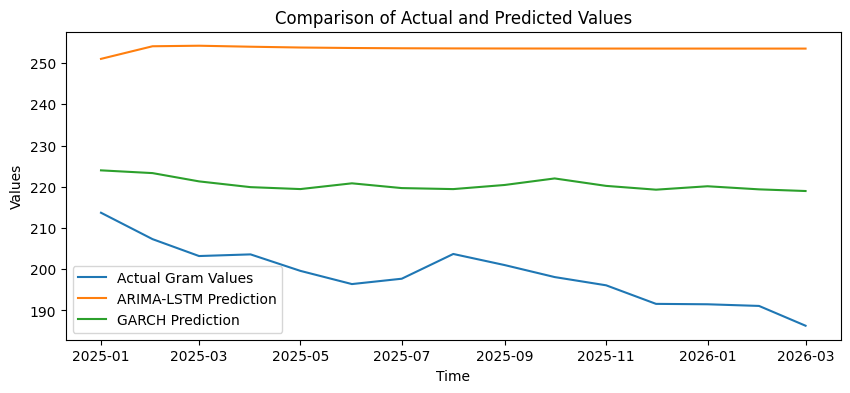

In [486]:
plt.figure(figsize=(10, 4))
plt.plot(test['Gram'], label='Actual Gram Values')
plt.plot(test['ARIMA-LSTM_Pred'], label='ARIMA-LSTM Prediction')
plt.plot(test['GARCH_prediction'], label='GARCH Prediction')

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Comparison of Actual and Predicted Values")
plt.legend()
plt.show()

In [487]:
rmse(test['Gram'],test['ARIMA-LSTM_Pred'])

np.float64(55.229693112992564)

In [488]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [489]:
mean_absolute_percentage_error(test['Gram'],test['ARIMA-LSTM_Pred'])

np.float64(27.713493444176663)

In [490]:
test.to_csv('Gram_result with ARIMA-LSTM Random forecst.csv')

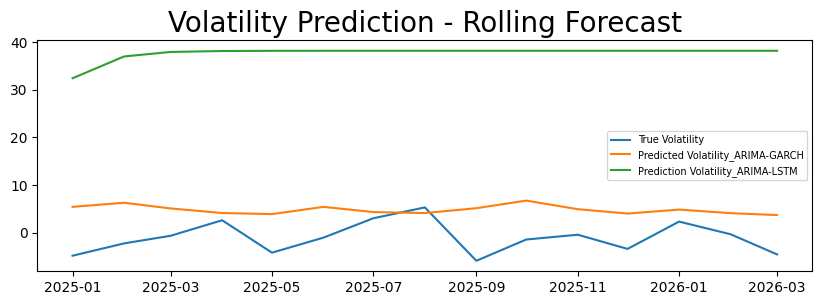

In [491]:
plt.figure(figsize=(10,3))
true, = plt.plot(resid_test)
preds, = plt.plot(rolling_predictions)
pred, = plt.plot(test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'])
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility_ARIMA-GARCH','Prediction Volatility_ARIMA-LSTM'], fontsize=7)